# 05 — SuperARC-seq

Produces **Table 1** and four figures:

* **Ranking by SuperARC-seq**
* **Percentages by output types: p₁…p₄**
* **Test scores when different types of sequences are considered**
* **Bootstrap** over 25, 50, 75 and 100 sequences

This is the part of the paper that does not ask whether a model got the answer
right. It asks whether the answer was a *model* of the sequence or a restatement
of it.

Three things can make an answer "correct":

| class | what the model did | worth |
|---|---|---|
| ρ₁ | gave a rule that generates the sequence | **1** |
| ρ₂ | mapped the index to the value, term by term | 0.1 |
| ρ₃ | reprinted the sequence | 0.01 |
| ρ₄ | got it wrong | 0 |

A lookup table is correct and explains nothing. That is what the weights
`(1, 0.1, 0.01)` encode: a genuine rule is worth a hundred times a reprint.

Then each of the first three classes is weighted by **how much it compressed** —
the harmonic mean of `tanh(BDM(sequence) / BDM(formula))`. Harmonic, not
arithmetic, so one incompressible answer cannot be offset by several good ones.

$$\varphi = \sum_{i=1}^{3} \rho_i\, \delta_i\, w_i$$

A perfect compressor scores 1.

**No logic lives in this notebook.** The metric comes from `superarc.table1`,
which owns it; the figures come from `superarc.superarc_seq`.

In [1]:
import pandas as pd
from superarc.notebook import figure

from superarc import table1
from superarc.superarc_seq import (
    MODEL_ORDER,
    PROB_LABELS,
    REFERENCE_ROW,
    RESHAPE_ORDER,
    SEQUENCE_SETS,
    assign_tiers,
    bootstrap,
    get_model_display_name,
    load,
    plot_bootstrap,
    plot_phi_by_type,
    plot_probabilities,
    plot_ranking,
    proportions_by_type,
    ranking,
    scores_by_type,
    subset,
)

pd.set_option("display.width", 170)

df = load()
print(f"{len(df)} sequences x {len(df.columns)} columns, {len(MODEL_ORDER)} models")
pd.DataFrame({"sequence set": list(SEQUENCE_SETS),
              "rows": [len(subset(df, n)) for n in SEQUENCE_SETS]})

190 sequences x 229 columns, 28 models


,sequence set,rows
0,Binary,100
1,Integers Type 1,30
2,Integers Type 2,30
3,Integers Type 3,30


## What the score consumes

φ is built from three boolean columns per model: `-formula-correctness`,
`-formula-ordinal` and `-formula-copy_seq`. **Nothing in this repository computes
them.** They are hand-adjudicated, one judgement per model per sequence — roughly
2,800 of them. Automating that is the one remaining piece of the pipeline.

Everything else is mechanical: the formula text and the sequence text go into
BDM, and the rest is arithmetic.

In [2]:
binary = subset(df, "Binary")
# Claude-3.5 is the one model with answers in three different classes on the
# binary set, so it shows the whole metric rather than one corner of it.
column = "claude_3.5"
sample = binary[["sequence", f"{column}-formula",
                 f"{column}-formula-correctness",
                 f"{column}-formula-ordinal",
                 f"{column}-formula-copy_seq"]].head(4)
sample.columns = ["sequence", "formula", "correct", "ordinal", "copy"]
sample

,sequence,formula,correct,ordinal,copy
0,"1,1,0,0,0,1,0,0,0,0,1,0",f(n) = (n mod 5 == 0 || n mod 5 == 1) && n < 5,False,False,False
1,"0,0,0,1,0,1,1,0,1,0,1,1",f(n) = (n + 3) mod 4 == 0 || (n - 2) mod 7 == 0,False,False,False
2,"1,0,0,0,0,1,1,1,1,0,0,1",f(n) = n mod 6 >= 4 && n < 10,False,False,False
3,"1,1,1,1,1,1,1,1,0,1,0,0",f(n) = n < 8 || n == 9,True,False,False


### The four classes, for one model

Note that ρ₂ and ρ₃ are **not exclusive**: an answer that is both an index
mapping and a verbatim copy is counted in both, so the four counts can exceed the
number of sequences. ρ is therefore normalised by their total, not by the row
count. Preserved as published — it is how the printed table was computed.

In [3]:
masks = table1.class_masks(binary, column)
counts = [int(m.sum()) for m in masks]
rho, delta, phi = table1.score(binary, column)

pd.DataFrame({
    "class": ["rho1  rule", "rho2  ordinal", "rho3  copy", "rho4  wrong"],
    "answers": counts,
    "proportion": rho.round(4),
    "compression delta": list(delta.round(4)) + [None],
    "weight": list(table1.CLASS_WEIGHTS) + [None],
}).set_index("class")

,answers,proportion,compression delta,weight
class,,,,
rho1 rule,6,0.06,0.4493,1.00
rho2 ordinal,14,0.14,0.4284,0.10
rho3 copy,0,0.00,0.0000,0.01
rho4 wrong,80,0.80,NaN,NaN


In [4]:
contribution = rho[:3] * delta * table1.CLASS_WEIGHTS
print(f"{get_model_display_name(column)}")
for i, c in enumerate(contribution):
    print(f"  rho{i+1} x delta{i+1} x w{i+1} = {c:.6f}")
print(f"  {'phi':>26s} = {phi:.6f}   (matches table1.score: {phi == contribution.sum()})")

Claude-3.5
  rho1 x delta1 x w1 = 0.026960
  rho2 x delta2 x w2 = 0.005998
  rho3 x delta3 x w3 = 0.000000
                         phi = 0.032957   (matches table1.score: True)


## Table 1

Table 1 was **never written to disk**. The published script builds the frame and
then evaluates `np.round(df_ranking2, 3)` as a bare expression — which displays in
a notebook and does nothing in a script — so the printed table was transcribed
from a notebook cell by hand. `superarc.table1` emits it, and
`tests/test_table1.py` checks it against what was printed.

In [5]:
table = table1.compute()
table.round(3).set_index("Model")

,rho1,rho2,rho3,rho4,delta1,delta2,delta3,phi
Model,,,,,,,,
AIXI/BDM/CTM,1.00,0.00,0.0,0.00,1.000,0.000,0.000,1.000
ChatGPT-4.5,0.00,1.00,0.0,0.00,0.000,0.419,0.000,0.042
o1-Mini,0.00,0.64,0.0,0.36,0.000,0.537,0.000,0.034
Claude-3.7,0.00,0.81,0.0,0.19,0.000,0.407,0.000,0.033
Claude-3.5,0.06,0.14,0.0,0.80,0.449,0.428,0.000,0.033
o1-Preview,0.00,0.29,0.0,0.71,0.000,0.423,0.000,0.012
ChatGPT-4o-Mini,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
Gemini,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
Cursor-Small,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008


The top row is the reference: an optimal compressor answers everything
correctly, never by copying or index-mapping, and compresses fully. **No model
comes close.** The best is two orders of magnitude below it, and that gap is the
result the paper exists to report.

Note the labelling: this row is printed as `AIXI/BDM/CTM` in Table 1 and as `ASI`
in the ranking figure. Same row, two labels in print; both preserved.

## The ranking figure

Same numbers as Table 1, in the figure's own column names.

In [6]:
rank = ranking(df)
rank.round(4).set_index("Model").head(8)

,p1,p2,p3,p4,r1,r2,r3,tst
Model,,,,,,,,
ASI,1.00,0.00,0.0,0.00,1.0000,0.0000,1.0000,1.0000
ChatGPT-4.5,0.00,1.00,0.0,0.00,0.0000,0.4191,0.0000,0.0419
o1-Mini,0.00,0.64,0.0,0.36,0.0000,0.5372,0.0000,0.0344
Claude-3.7,0.00,0.81,0.0,0.19,0.0000,0.4070,0.0000,0.0330
Claude-3.5,0.06,0.14,0.0,0.80,0.4493,0.4284,0.0000,0.0330
o1-Preview,0.00,0.29,0.0,0.71,0.0000,0.4229,0.0000,0.0123
Gemini,0.00,0.00,1.0,0.00,0.0000,0.0000,0.7616,0.0076
Cursor-Small,0.00,0.00,1.0,0.00,0.0000,0.0000,0.7616,0.0076


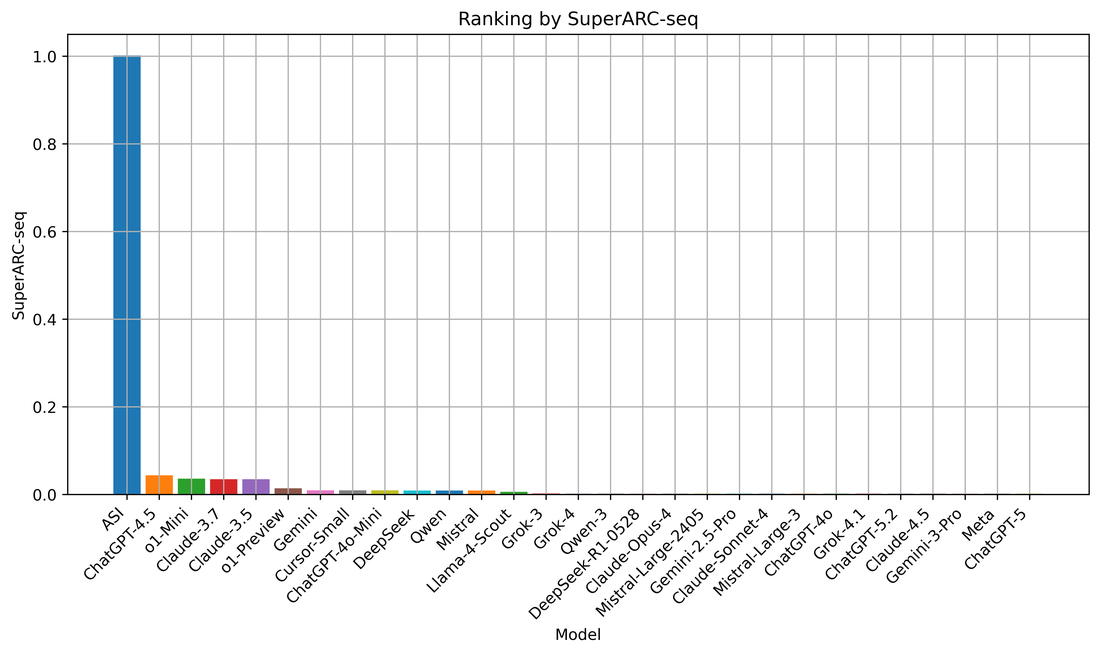

In [7]:
plot_ranking(rank)
figure("figure05.png")

## By type of sequence

The 100 binary sequences are the benchmark proper. The dataset also holds three
sets of 30 integer sequences, and the next two figures ask whether the picture
changes when the sequences do.

### The defect this figure had

Both figures flatten a table of 4 sequence sets × 28 models into one array,
reshape it, transpose it, and then **assign** the model list as the index. The
reshape is what decides which row each model gets — and nothing downstream can
detect a mistake in it. The figure plots either way, and every number in it is a
real number that some model really scored. It is simply on the wrong row.

The published p₁–p₄ figure reshaped with `order='F'`, which fills column by
column. The published φ figure, written a few lines below it, used the default C
order and was right.

In [8]:
import numpy as np

labels, models = ["Binary", "Int 1", "Int 2", "Int 3"], [f"model{i}" for i in range(28)]
flat = np.array([f"{ll}|{m}" for ll in labels for m in models], dtype=object)

wrong = pd.DataFrame(flat.reshape(4, 28, order="F")).T
right = pd.DataFrame(flat.reshape(4, 28)).T
for frame in (wrong, right):
    frame.index, frame.columns = models, labels

print("order='F', as published:")
print(wrong.head(3).to_string())
print("\norder='C', the correction:")
print(right.head(3).to_string())
misplaced = sum(wrong.loc[m, ll] != f"{ll}|{m}" for m in models for ll in labels)
print(f"\ncells landing on the wrong (model, set): {misplaced} of {28*4}")

order='F', as published:
               Binary          Int 1           Int 2           Int 3
model0  Binary|model0  Binary|model1   Binary|model2   Binary|model3
model1  Binary|model4  Binary|model5   Binary|model6   Binary|model7
model2  Binary|model8  Binary|model9  Binary|model10  Binary|model11

order='C', the correction:
               Binary         Int 1         Int 2         Int 3
model0  Binary|model0  Int 1|model0  Int 2|model0  Int 3|model0
model1  Binary|model1  Int 1|model1  Int 2|model1  Int 3|model1
model2  Binary|model2  Int 1|model2  Int 2|model2  Int 3|model2

cells landing on the wrong (model, set): 108 of 112


Applied to the real data, 173 of the 448 plotted points showed a number
belonging to a different model or a different sequence set. The other 275
coincided — many class proportions are zero, or repeat across models — which is
exactly why it survived review.

Here is the model it distorted most visibly:

In [9]:
props = proportions_by_type(df)
column = "gpt_4o"
label = get_model_display_name(column)

rows = []
for name in SEQUENCE_SETS:
    rho, _d, _p = table1.score(subset(df, name), column)
    drawn = [float(props[(props.c1 == label) & (props.c2 == name)
                         & (props.Prob == p)]["values"].iloc[0])
             for p in PROB_LABELS]
    rows.append({"sequence set": name,
                 "p1 now": round(drawn[0], 3), "p1 true": round(rho[0], 3),
                 "p4 now": round(drawn[3], 3), "p4 true": round(rho[3], 3)})
print(f"{label}: the figure now draws its own numbers (RESHAPE_ORDER = {RESHAPE_ORDER!r})")
pd.DataFrame(rows)

ChatGPT-4o: the figure now draws its own numbers (RESHAPE_ORDER = 'C')


,sequence set,p1 now,p1 true,p4 now,p4 true
0,Binary,0.000,0.000,1.000,1.000
1,Integers Type 1,1.000,1.000,0.000,0.000
2,Integers Type 2,0.367,0.367,0.033,0.033
3,Integers Type 3,0.000,0.000,0.233,0.233


As printed, that row read `p₁ = 0.000` on every sequence set — the model got
nothing right anywhere. On Integers Type 1 its true p₁ is **1.000**: every answer
correct, none of them a copy or an index mapping.

### The figures

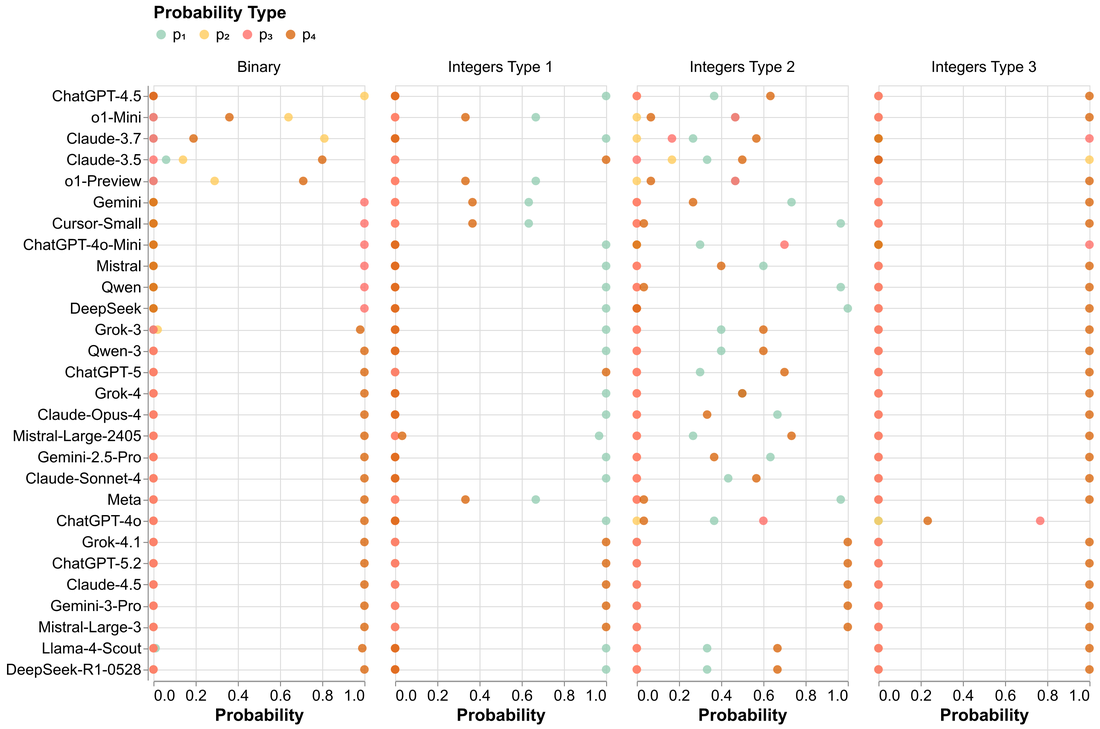

In [10]:
plot_probabilities(props)
figure("figure06.png")

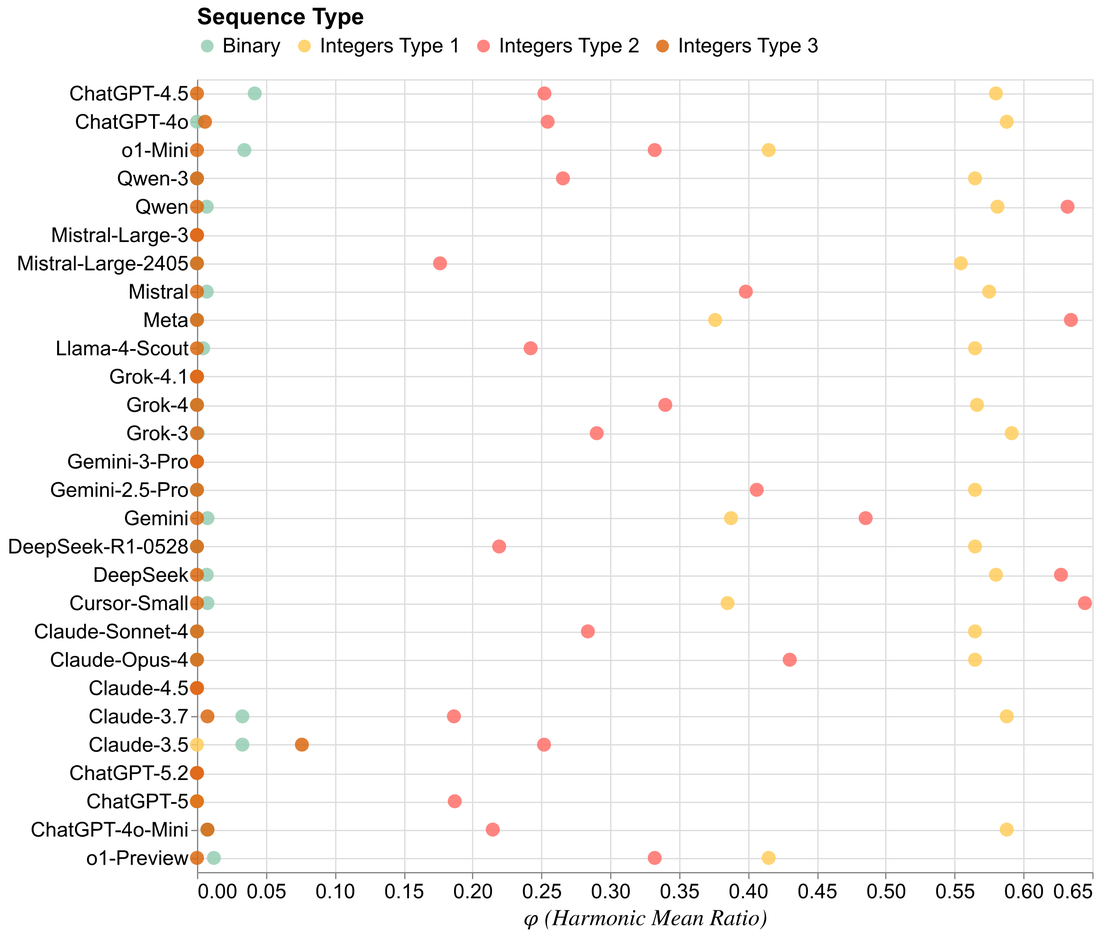

In [11]:
phi_by_type = scores_by_type(df)
plot_phi_by_type(phi_by_type, props)
figure("figure07.png")

### One more thing about these two figures

They sort their y-axis by the sum of the class proportions. But proportions sum
to 1 on every sequence set, so that key is **exactly 4.0 for every model**. It
cannot order anything.

Under the published reshape the summation ran over a differently ordered set of
addends, so floating point returned 3.99999999999999956 for some models and 4.0
for others — a spread of 4.4×10⁻¹⁶. That is what ordered the rows.

So the apparent top-to-bottom ranking in both figures was never a ranking. With
the reshape corrected the tie is exact and the order is at least stable. Giving
them a real sort key would be a design change rather than a correction, so it is
left as it is.

In [12]:
key = props.groupby("c1")["values"].sum()
print(f"sort key: {key.nunique()} distinct value(s) across {len(key)} models")
print(f"          min {key.min():.17f}")
print(f"          max {key.max():.17f}")
print(f"          spread {key.max() - key.min():.2e}")

sort key: 1 distinct value(s) across 28 models
          min 4.00000000000000000
          max 4.00000000000000000
          spread 0.00e+00


## The bootstrap

Does the ranking survive being computed on fewer sequences? Resample the 100
binary sequences with replacement at sizes 25, 50, 75 and 100, a hundred times
each, and rescore.

`np.random.seed()` seeds the *legacy* global RNG. `np.random.default_rng()` with
no argument builds a fresh Generator from OS entropy and ignores it entirely, so
the published bootstrap was never reproducible. It is seeded now. One consequence:
o1-Mini's displayed mean becomes 0.034 rather than the published 0.035 — its
exact, non-bootstrap score is 0.034380, so 0.034 is the correctly rounded value
and the published figure showed the noisier draw.

This cell runs 400 resamples over 28 models. It used to be farmed out to a
process pool; with BDM memoised that work is gone and it now takes about two
seconds in one process — measured at 1.89 s on one core against 1.84 s on eight,
with a bit-identical result. The pool was also emitting a hundred lines of
teardown errors on every run, which is the kind of noise that hides a real
failure.

In [13]:
df_bts = bootstrap(df)
tiered, means = assign_tiers(df_bts)
means.round(4).to_frame("mean test score").head(10)

,mean test score
Model,
ChatGPT-4.5,0.0419
o1-Mini,0.0343
Claude-3.5,0.0331
Claude-3.7,0.0328
o1-Preview,0.0124
ChatGPT-4o-Mini,0.0076
Cursor-Small,0.0076
Gemini,0.0076
Qwen,0.0071


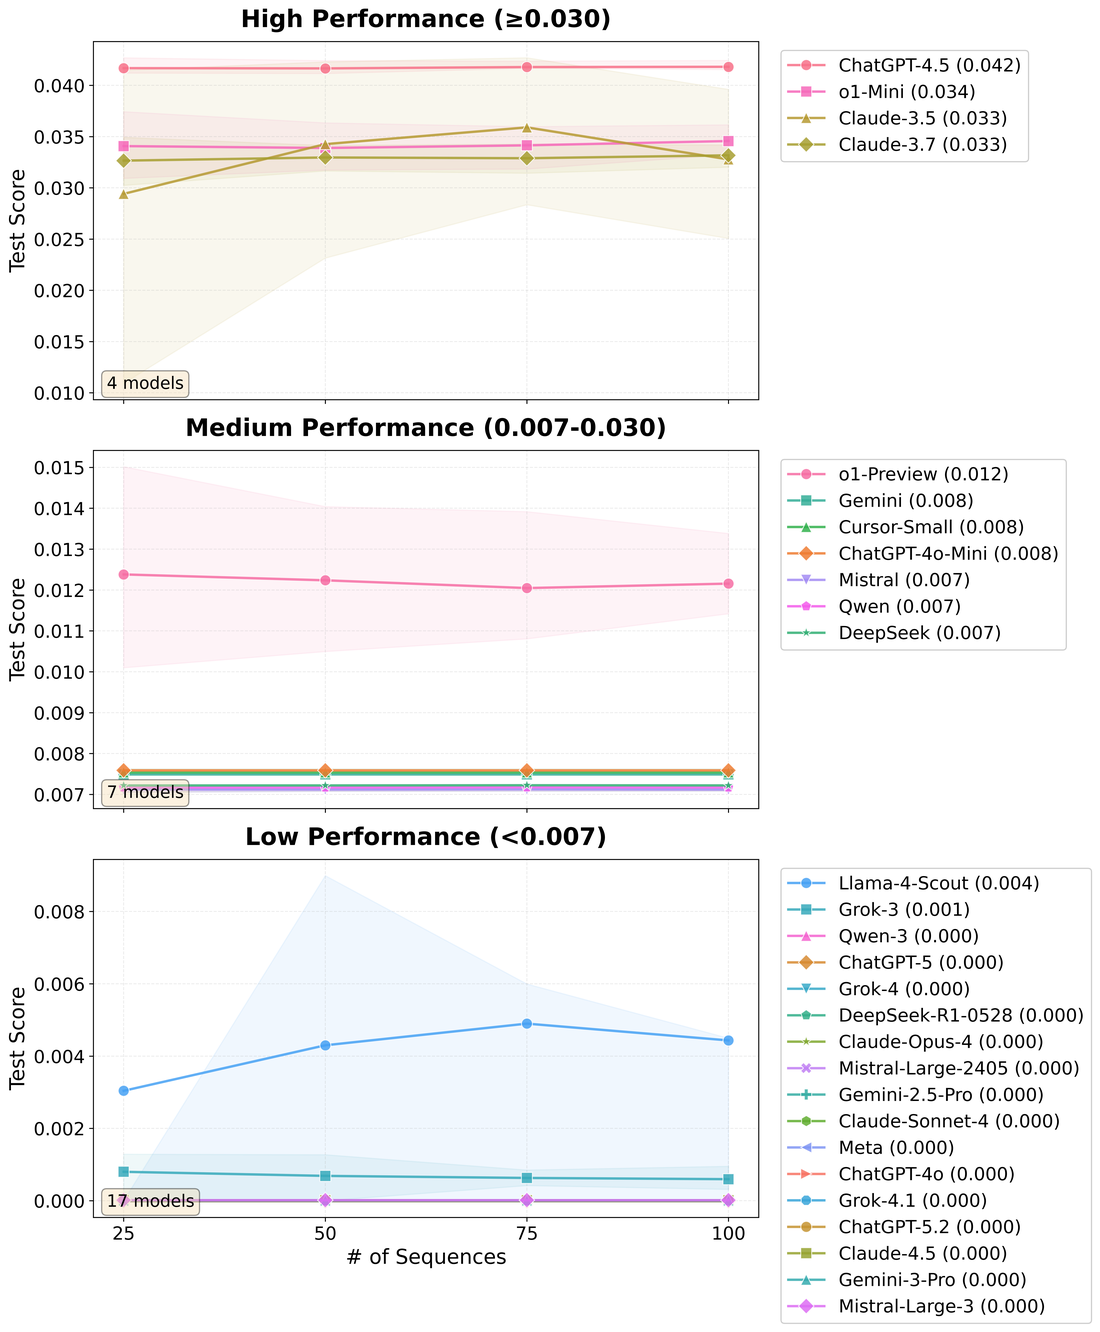

In [14]:
plot_bootstrap(df_bts)
figure("figure08.png")

The tiers are cut at 0.030 and 0.007. What the figure shows is that the
tiers are stable across sample size while the individual lines inside a tier are
not — the ordering *within* a tier is not resolvable from 100 sequences.

## Verification

In [15]:
from superarc.parity import check_figures

check_figures(["figure05.png", "figure06.png", "figure07.png", "figure08.png"])

,figure,status,detail
0,Fig 7 SuperARC-seq ranking,matches published,0.0000% of pixels differ
1,figure06.png,changed,p1-p4 by sequence type -- CORRECTED: the resha...
2,figure07.png,changed,"phi by sequence type -- REORDERED, values unch..."
3,figure08.png,changed,bootstrap tiers -- RESEEDED: published draw ca...


In [16]:
import subprocess

dirty = subprocess.run(
    ["git", "status", "--porcelain", "new_plots/", "plots/"],
    capture_output=True, text=True, cwd="..",
).stdout.strip()

print(dirty if dirty else "clean: no published figure was modified")

clean: no published figure was modified


### Where this code lives

`34-2_S-ARC_ext.py` is now a forwarder onto `superarc.superarc_seq`. It is kept,
not deleted, because it is the path that produced the published figures.

The script inlined the same score **four times** — for Table 1 and the ranking,
for the p-only version behind the probabilities figure, for the φ figure, and
inside the bootstrap's inner loop. A change to the benchmark had to be made in
four places or in none. They are one call to `superarc.table1.score` now, checked
against all four before they were removed, including the one place they could
have differed: the script used `statistics.harmonic_mean`, which returns 0 when
any value is 0, while `table1.harmonic_mean` drops non-positive values first. No
class group in this dataset contains a zero, so the two agree on every one of
them.

The script also carried its own 28-entry display map — 28 of 28 agreed with the
registry — and the last copy of `ascii_to_binary_list`.

Before the move, all four figures reproduced the old script at **0.0000% pixel
difference** and Table 1 was unchanged. Then the reshape correction was applied,
and only the two figures that used the reshape moved.

One more thing: BDM of a string is a pure function, and the same few hundred
strings are measured once per model and once per bootstrap resample. Memoising it
took the full run from **29.2 s to 6.5 s** with every figure still pixel-identical.
Two tests hold the cache to an uncached engine.